# YOLO flow plan for Google Colab

Step 0. **Verify NVIDIA GPU Availability**

Make sure you're using a GPU-equipped machine by going to "Runtime" -> "Change runtime type" in the top menu bar, and then selecting one of the GPU options in the Hardware accelerator section. Click Play on the following code block to verify that the NVIDIA GPU is present and ready for training.   usually T4 GPU


In [1]:
!nvidia-smi

Tue Apr 21 17:19:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   57C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

#1.&nbsp;Gather and Label Training Images

Before we start training, we need to gather and label images that will be used for training the object detection model. A good starting point for a proof-of-concept model is 200 images. The training images should have random objects in the image along with the desired objects, and should have a variety of backgrounds and lighting conditions.

There are a couple options for gathering images:

Build a custom dataset by taking your own pictures of the objects and labeling them (this typically results in the best performance)
Find a pre-made dataset from sources like Roboflow Universe, Kaggle, or Google Images V7
If you want to build your own dataset, there are several tools available for labeling images. One good option is Label Studio, a free and open-source labeling tool that has a simple workflow while providing capabilities for more advanced features.

If you used Label Studio to label and export the images, they'll be exported in a project.zip file that contains the following:

An images folder containing the images
A labels folder containing the labels in YOLO annotation format
A classes.txt labelmap file that contains all the classes
A notes.json file that contains info specific to Label Studio (this file can be ignored)
If you obtained your dataset from another source (like Roboflow Universe) or used another tool to label your dataset, make sure the files are organized in the same folder structure.

Once you've got your dataset built, put into the file structure shown above, and zipped into data.zip, you're ready to move on to the next step.

# 2.&nbsp;Upload Image Dataset and Prepare Training Data

Next, we'll prepare the Pix3D dataset for training with YOLO. Since the dataset has already been downloaded from Kaggle and uploaded to Google Drive, we do not need to upload files manually into Colab.

Instead, we'll mount Google Drive, verify the dataset location, and then prepare the dataset for training.



## 2.1 Mount Google Drive

In this step, we'll connect Google Drive to the Colab session so the notebook can access the downloaded Pix3D dataset.

After mounting, your Drive files will be available under:

/content/drive/MyDrive/

First, upload the data.zip file to your Google Drive, and make note of the folder you uploaded them to. Replace MyDrive/path/to/data.zip with the path to your zip file. (For example, I uploaded the zip file to folder called "candy-dataset1", so I would use MyDrive/candy-dataset1/data.zip for the path). Then, run the following block of code to mount your Google Drive to this Colab session and copy the folder to this filesystem.

First, we mount Google Drive to access the dataset ZIP file. Then, we copy the ZIP file into the Colab working directory.

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive

'Colab Notebooks'   furniture_images.zip


In [ ]:
!cp /content/drive/MyDrive/furniture_images.zip /content/data.zip

## 2.2 Split images into train and validation folders

At this point, whether you used Option 1, 2, or 3, you should be able to click the folder icon on the left and see your `data.zip` file in the list of files. Next, we'll unzip `data.zip` and create some folders to hold the images. Run the following code block to unzip the data.

In [ ]:
# Unzip images to a custom data folder
!unzip -q /content/data.zip -d /content/custom_data

Ultralytics requires a particular folder structure to store training data for models. Ultralytics requires a particular folder structure to store training data for models. The root folder is named “data”. Inside, there are two main folders:

*   **Train**: These are the actual images used to train the model. In one epoch of training, every image in the train set is passed into the neural network. The training algorithm adjusts the network weights to fit the data in the images.


*   **Validation**: These images are used to check the model's performance at the end of each training epoch.

In each of these folders is a “images” folder and a “labels” folder, which hold the image files and annotation files respectively.

I wrote a Python script that will automatically create the required folder structure and randomly move 90% of dataset to the "train" folder and 10% to the "validation" folder. Run the following code block to download and execute the scrpt.

In [ ]:
from pathlib import Path

print("Top level:")
for p in Path("/content/custom_data").iterdir():
    print(p)

Top level:
/content/custom_data/furniture_images


In [ ]:
import random, shutil
from pathlib import Path

BASE_DATA = Path("/content/custom_data/furniture_images")

SRC_IMG   = BASE_DATA / "img"
SRC_LABEL = BASE_DATA / "labels"

print("Using image path:", SRC_IMG)
print("Using label path:", SRC_LABEL)
print("Images path exists:", SRC_IMG.exists())
print("Labels path exists:", SRC_LABEL.exists())

# Output dirs
BASE = Path("/content/furniture_data_split")
IMG_TRAIN = BASE / "images" / "train"
IMG_VAL   = BASE / "images" / "val"
LBL_TRAIN = BASE / "labels" / "train"
LBL_VAL   = BASE / "labels" / "val"

for p in (IMG_TRAIN, IMG_VAL, LBL_TRAIN, LBL_VAL):
    p.mkdir(parents=True, exist_ok=True)

# Only keep images that have matching labels
all_imgs = []
for img_path in list(SRC_IMG.rglob("*.png")) + list(SRC_IMG.rglob("*.jpg")) + list(SRC_IMG.rglob("*.jpeg")):
    rel = img_path.relative_to(SRC_IMG)
    label_path = SRC_LABEL / rel.with_suffix(".txt")
    if label_path.exists():
        all_imgs.append(img_path)

print("Total labeled images:", len(all_imgs))

random.seed(42)
random.shuffle(all_imgs)

n_val = int(len(all_imgs) * 0.2)
val_set = set(all_imgs[:n_val])

for img_path in all_imgs:
    rel = img_path.relative_to(SRC_IMG)

    if img_path in val_set:
        dst_img = IMG_VAL / rel
        dst_lbl = LBL_VAL / rel.with_suffix(".txt")
    else:
        dst_img = IMG_TRAIN / rel
        dst_lbl = LBL_TRAIN / rel.with_suffix(".txt")

    dst_img.parent.mkdir(parents=True, exist_ok=True)
    dst_lbl.parent.mkdir(parents=True, exist_ok=True)

    shutil.copy(img_path, dst_img)
    shutil.copy(SRC_LABEL / rel.with_suffix(".txt"), dst_lbl)

yaml_txt = """
train: /content/furniture_data_split/images/train
val: /content/furniture_data_split/images/val

nc: 9
names:
  0: bed
  1: bookcase
  2: chair
  3: desk
  4: sofa
  5: table
  6: tool
  7: wardrobe
  8: misc
""".strip()

with open("/content/furniture_data_split.yaml", "w") as f:
    f.write(yaml_txt)

print("✅ Dataset ready!")
print("Train images:", len(all_imgs) - n_val)
print("Validation images:", n_val)
print("YAML:", "/content/furniture_data_split.yaml")

Using image path: /content/custom_data/furniture_images/img
Using label path: /content/custom_data/furniture_images/labels
Images path exists: True
Labels path exists: True
Total labeled images: 9922
✅ Dataset ready!
Train images: 7938
Validation images: 1984
YAML: /content/furniture_data_split.yaml


# 3.&nbsp;Install Requirements (Ultralytics)

Next, we'll install the Ultralytics library in this Google Colab instance. This Python library will be used to train the YOLO model.

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 61.0 MB/s eta 0:00:00


# 4.&nbsp;Configure Training

Explanation text

The dataset configuration YAML file has already been generated during dataset preparation. This file tells YOLO where the training and validation images are located, and defines the class names used during training.

The generated config file is:

/content/furniture_data_split.yaml

# 5.&nbsp;Train Model

## 5.1 Training Parameters
Now that the data is organized and the config file is created, we're ready to start training! First, there are a few important parameters to decide on. Visit my article on [Training YOLO Models Locally](https://www.ejtech.io/learn/train-yolo-models) to learn more about these parameters and how to choose them.

**Model architecture & size (`model`):**

There are several YOLO11 models sizes available to train, including `yolo11n.pt`, `yolo11s.pt`, `yolo11m.pt`, `yolo11l.pt`, and `yolo11xl.pt`. Larger models run slower but have higher accuracy, while smaller models run faster but have lower accuracy. I made a brief YouTube video that compares performance of different YOLO models on a Raspberry Pi 5 and a laptop with a RTX 4050 GPU, [check it out here to get a sense of their speed accuracy](https://youtu.be/_WKS4E9SmkA). If you aren't sure which model size to use, `yolo11s.pt` is a good starting point.

You can also train YOLOv8 or YOLOv5 models by substituting `yolo11` for `yolov8` or `yolov5`.


**Number of epochs (`epochs`)**

In machine learning, one “epoch” is one single pass through the full training dataset. Setting the number of epochs dictates how long the model will train for. The best amount of epochs to use depends on the size of the dataset and the model architecture. If your dataset has less than 200 images, a good starting point is 60 epochs. If your dataset has more than 200 images, a good starting point is 40 epochs.


**Resolution (`imgsz`)**

Resolution has a large impact on the speed and accuracy of the model: a lower resolution model will have higher speed but less accuracy. YOLO models are typically trained and inferenced at a 640x640 resolution. However, if you want your model to run faster or know you will be working with low-resolution images, try using a lower resolution like 480x480.


## 5.2 Run Training!

Run the following code block to begin training. If you want to use a different model, number of epochs, or resolution, change `model`, `epochs`, or `imgsz`.

In [ ]:
!yolo detect train data=/content/furniture_data_split.yaml model=yolo11s.pt epochs=40 imgsz=640

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/furniture_data_split.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, persp

The training algorithm will parse the images in the training and validation directories and then start training the model. At the end of each training epoch, the program runs the model on the validation dataset and reports the resulting mAP, precision, and recall. As training continues, the mAP should generally increase with each epoch. Training will end once it goes through the number of epochs specified by `epochs`.

> **NOTE:** Make sure to allow training to run to completion, because an optimizer runs at the end of training that strips out unneeded layers from the model.

The best trained model weights will be saved in `content/runs/detect/train/weights/best.pt`. Additional information about training is saved in the `content/runs/detect/train` folder, including a `results.png` file that shows how loss, precision, recall, and mAP progressed over each epoch.

#6.&nbsp;Test Model

The model has been trained; now it's time to test it! The commands below run the model on the images in the validation folder and then display the results for the first 10 images. This is a good way to confirm your model is working as expected. Click Play on the blocks below to see how your model performs.

In [ ]:
!yolo detect predict model=runs/detect/train/weights/best.pt source=data/validation/images save=True

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,129,841 parameters, 0 gradients, 28.5 GFLOPs

image 1/17 /content/data/validation/images/3c414ebf-candy_140.jpg: 384x640 1 snickers, 47.3ms
image 2/17 /content/data/validation/images/3f00aff8-candy_36.jpg: 384x640 1 airheads, 1 gummy_worms, 2 nerdss, 1 snickers, 1 starbust, 10.6ms
image 3/17 /content/data/validation/images/426f5963-candy_45.jpg: 384x640 1 MMs_peanut, 1 MMs_regular, 1 airheads, 1 milky_way, 1 three_musketeers, 10.6ms
image 4/17 /content/data/validation/images/470f8677-candy_51.jpg: 384x640 1 MMs_regular, 1 airheads, 1 milky_way, 1 snickers, 1 twizzlers, 10.6ms
image 5/17 /content/data/validation/images/516476d5-candy_115.jpg: 480x640 1 MMs_peanut, 1 airheads, 1 milky_way, 1 nerds, 1 twizzlers, 45.1ms
image 6/17 /content/data/validation/images/5251ce1a-candy_155.jpg: 384x640 1 airheads, 1 starbust, 11.2ms
image 7/17 /content/data/validation/images/5eb97

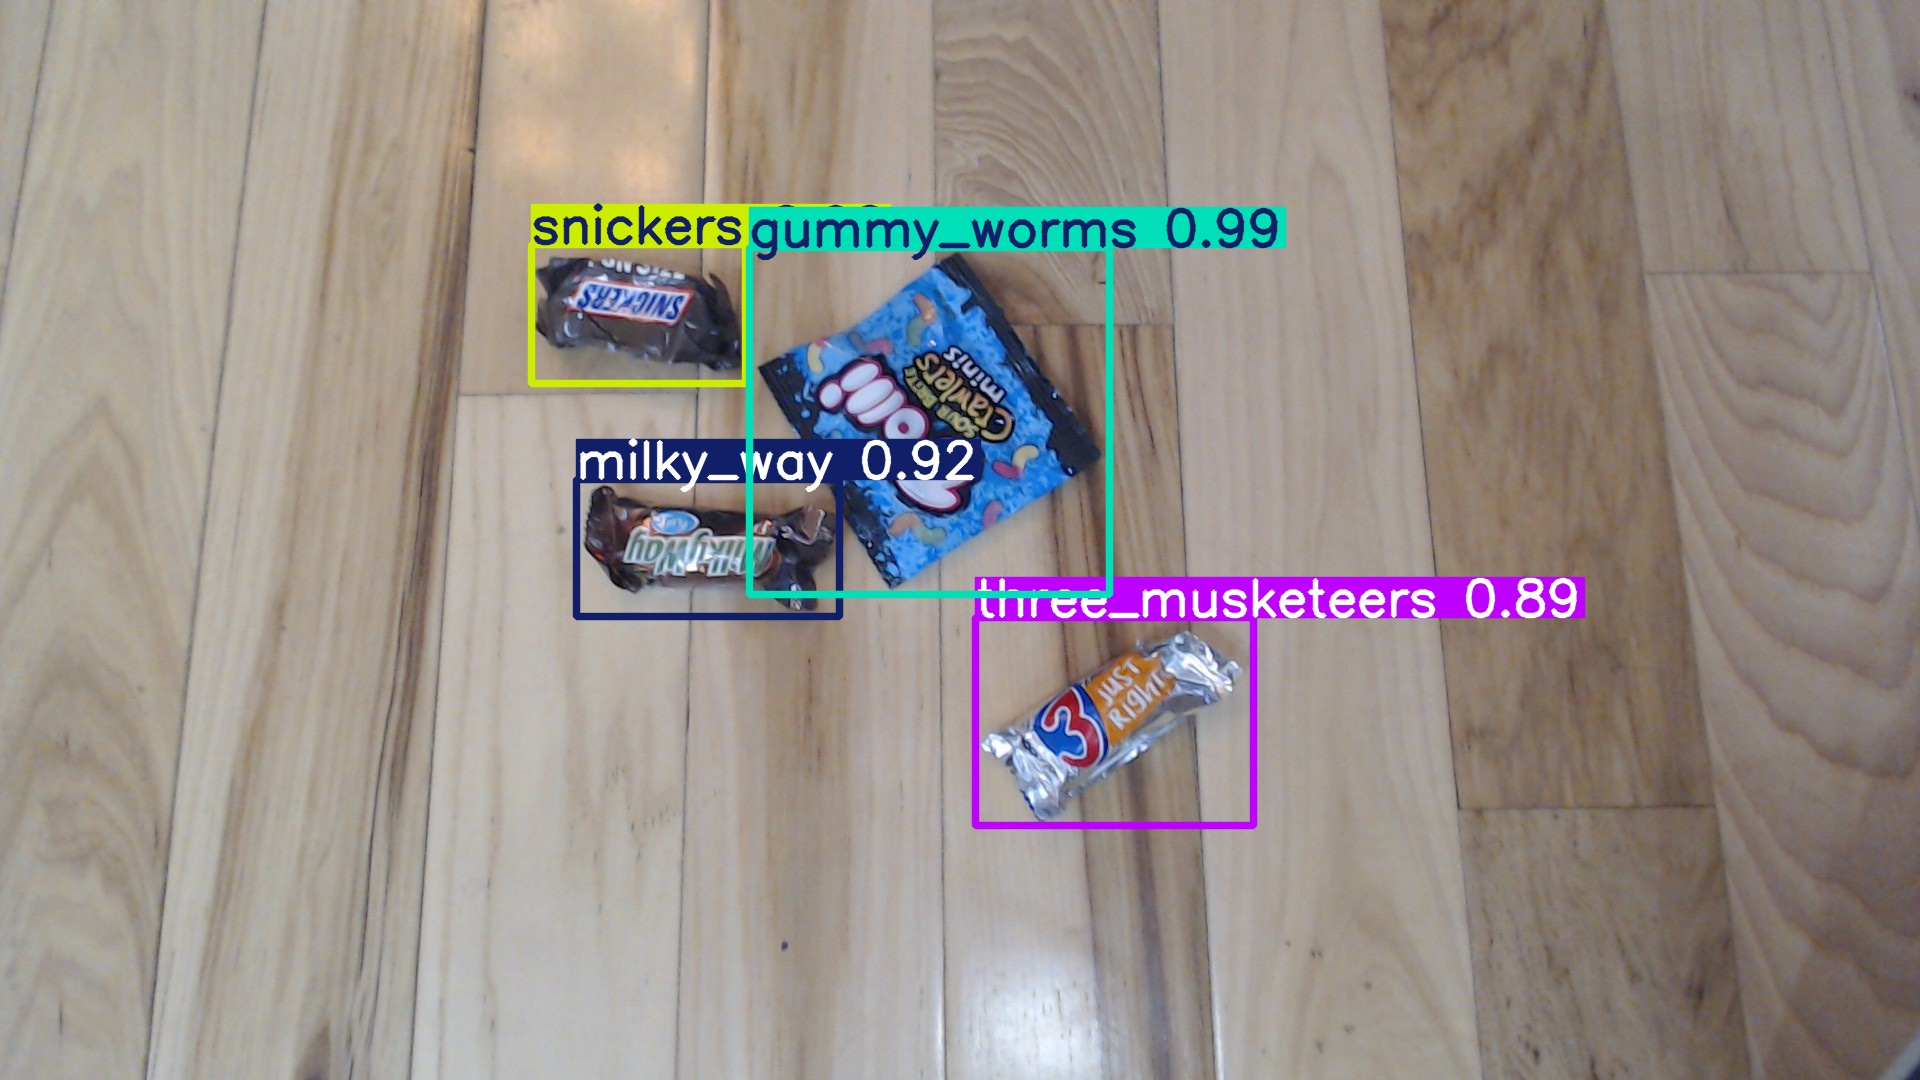

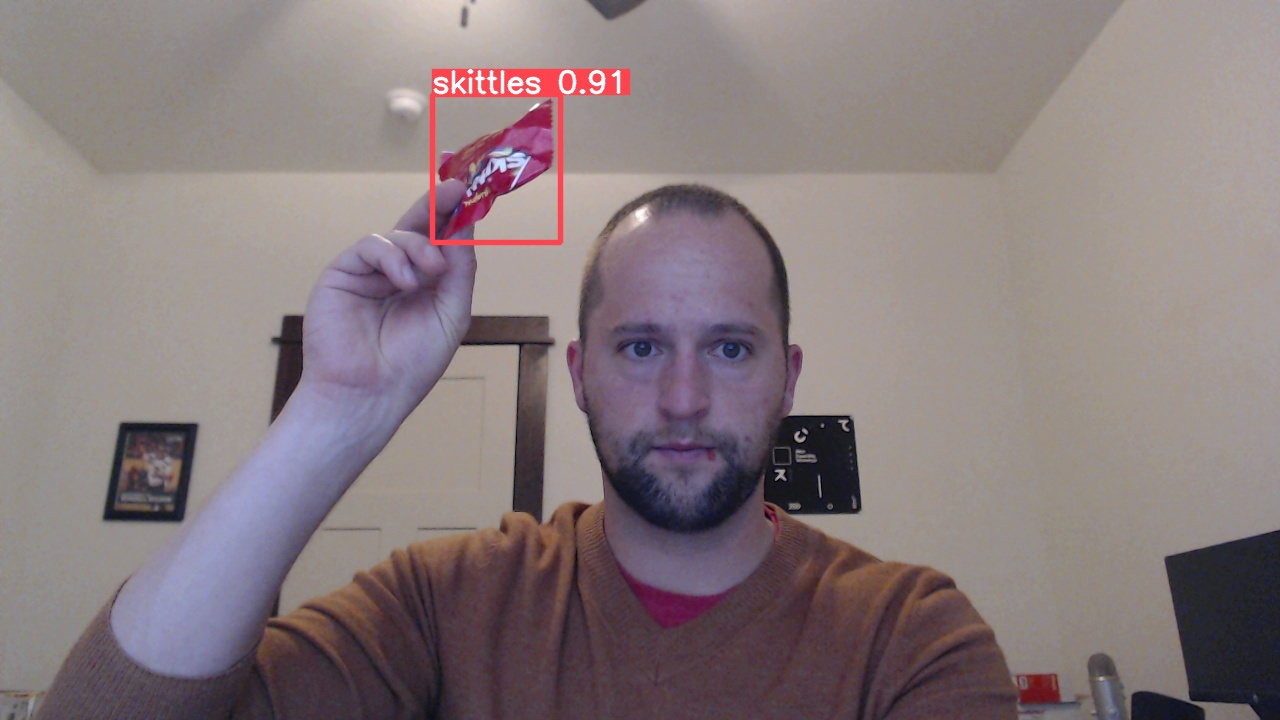

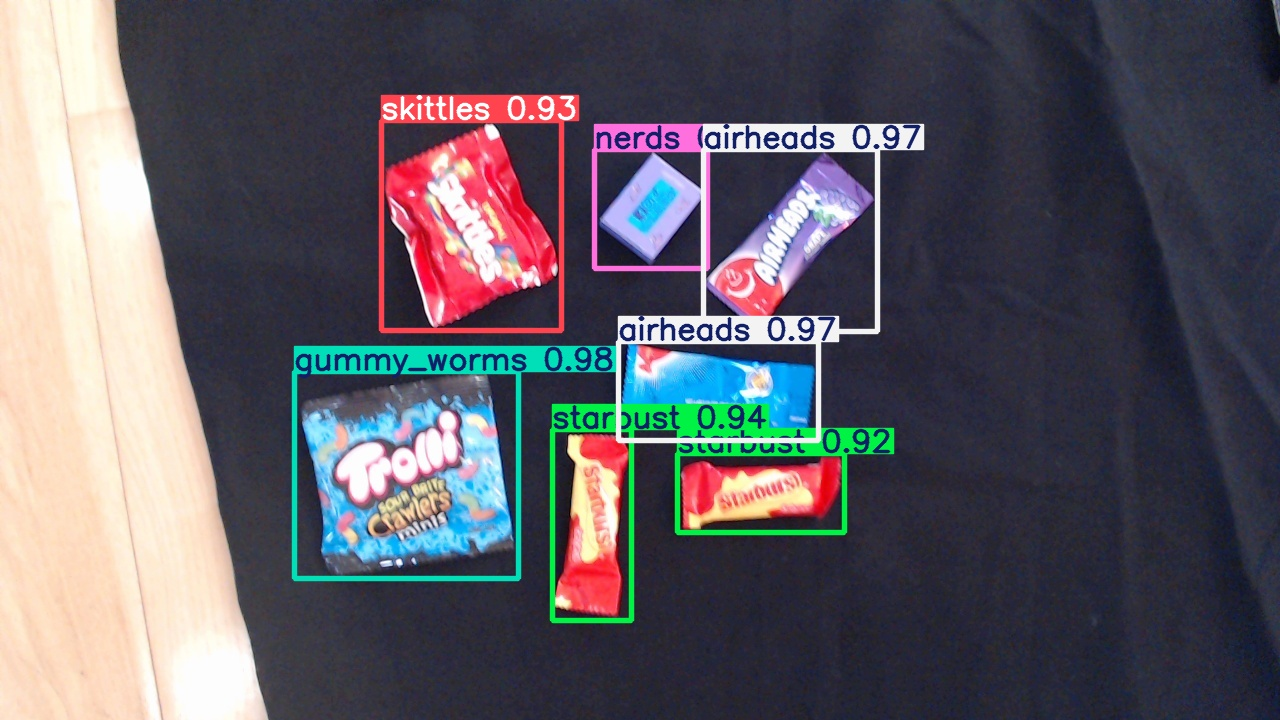

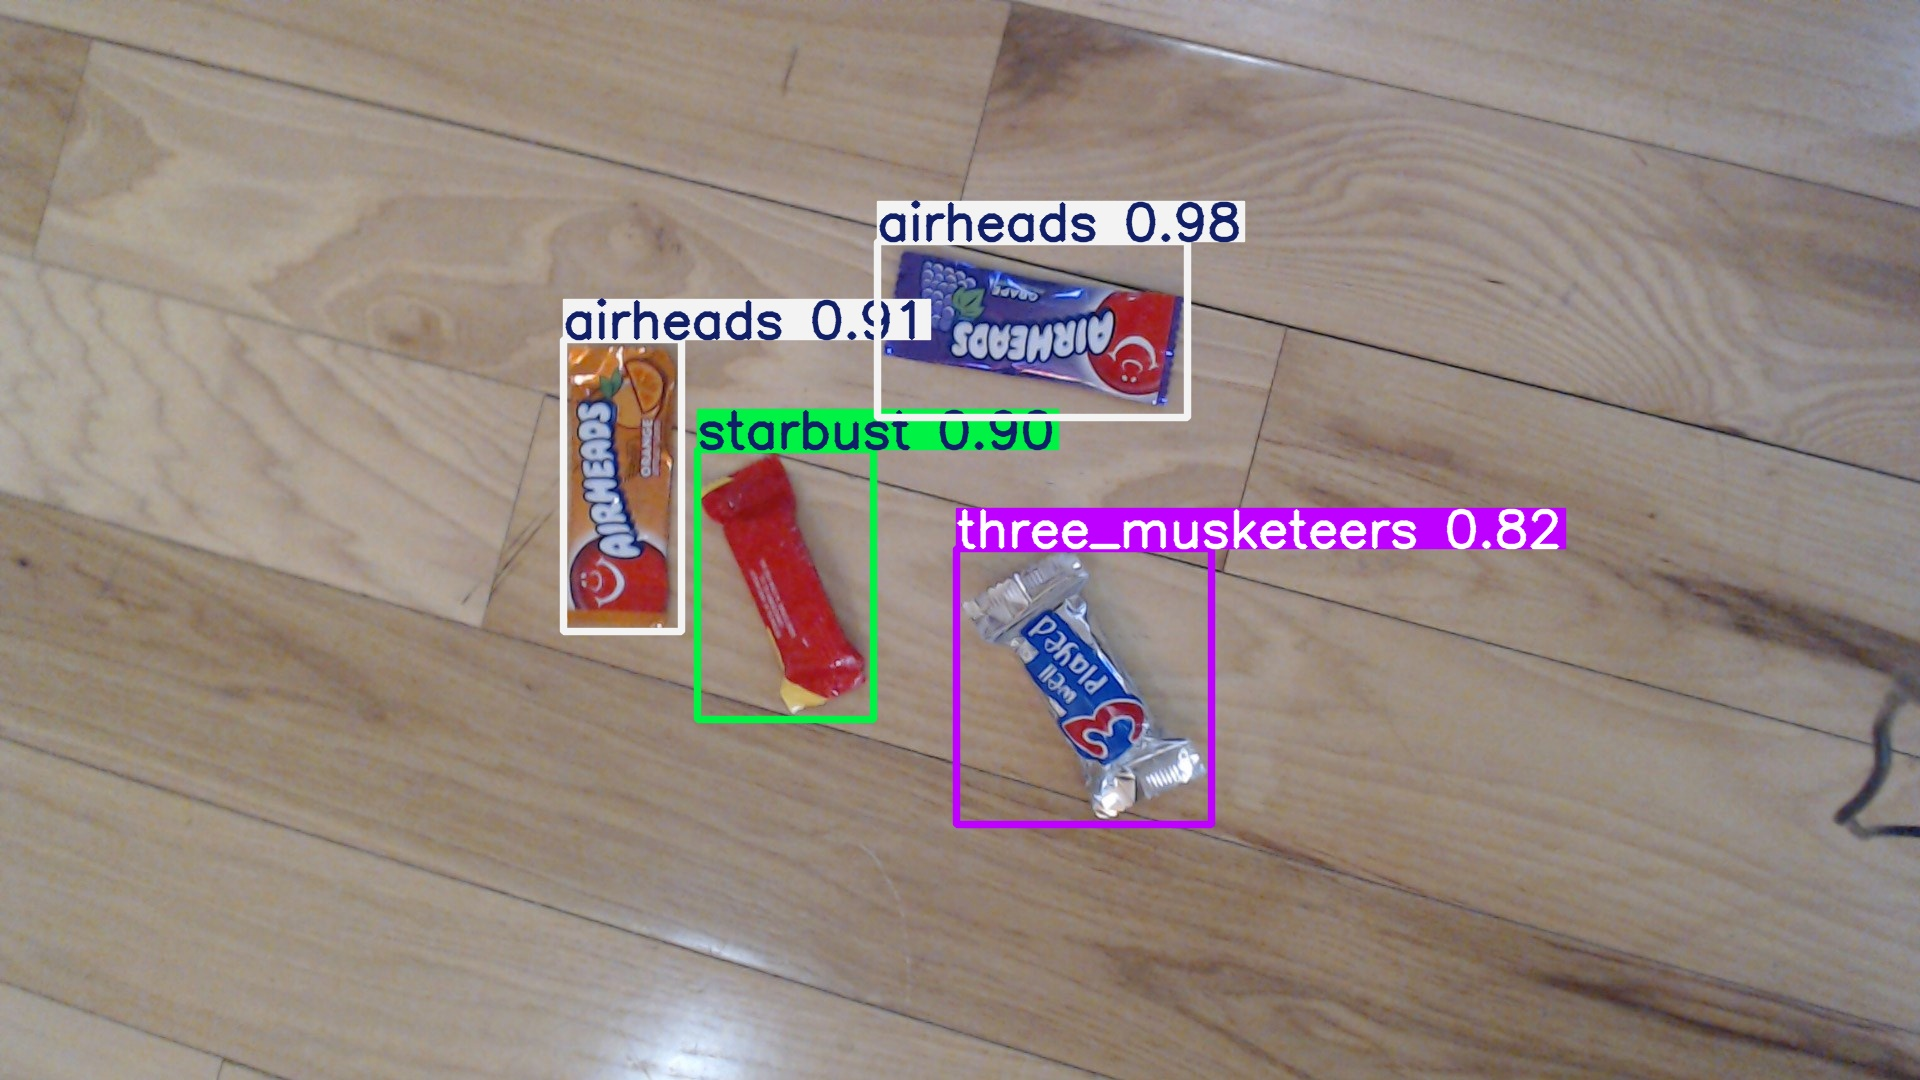

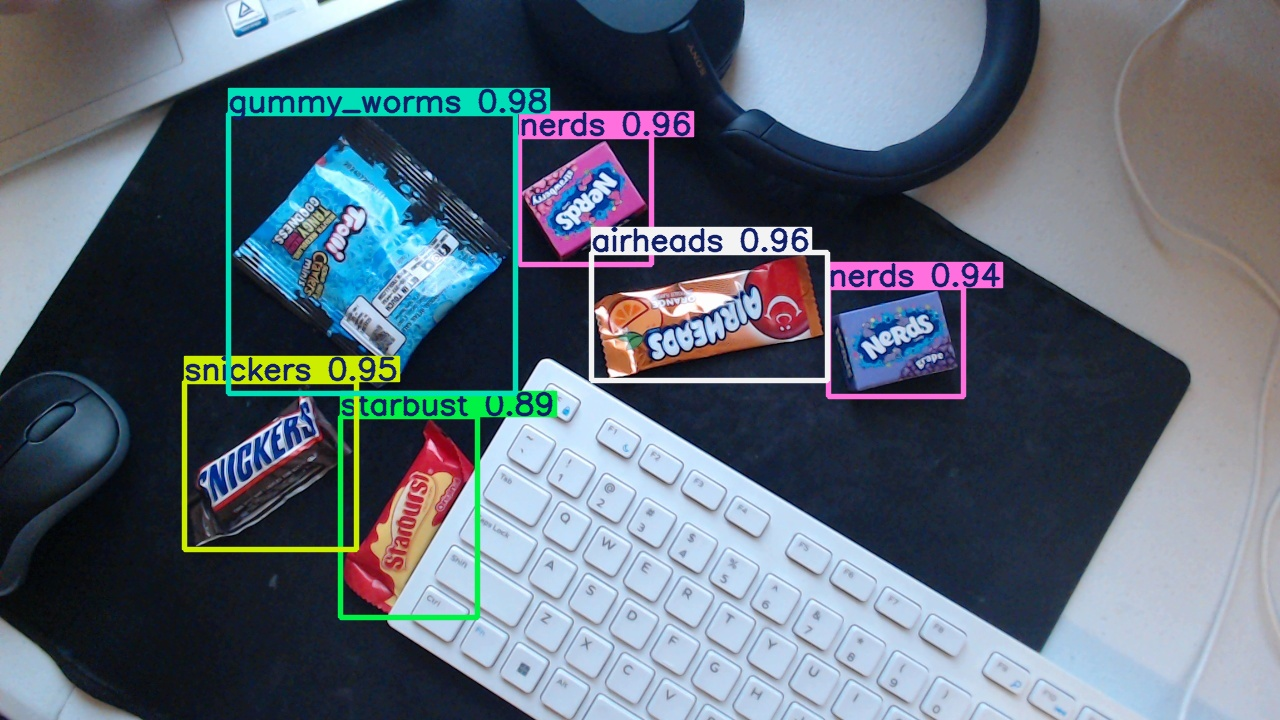

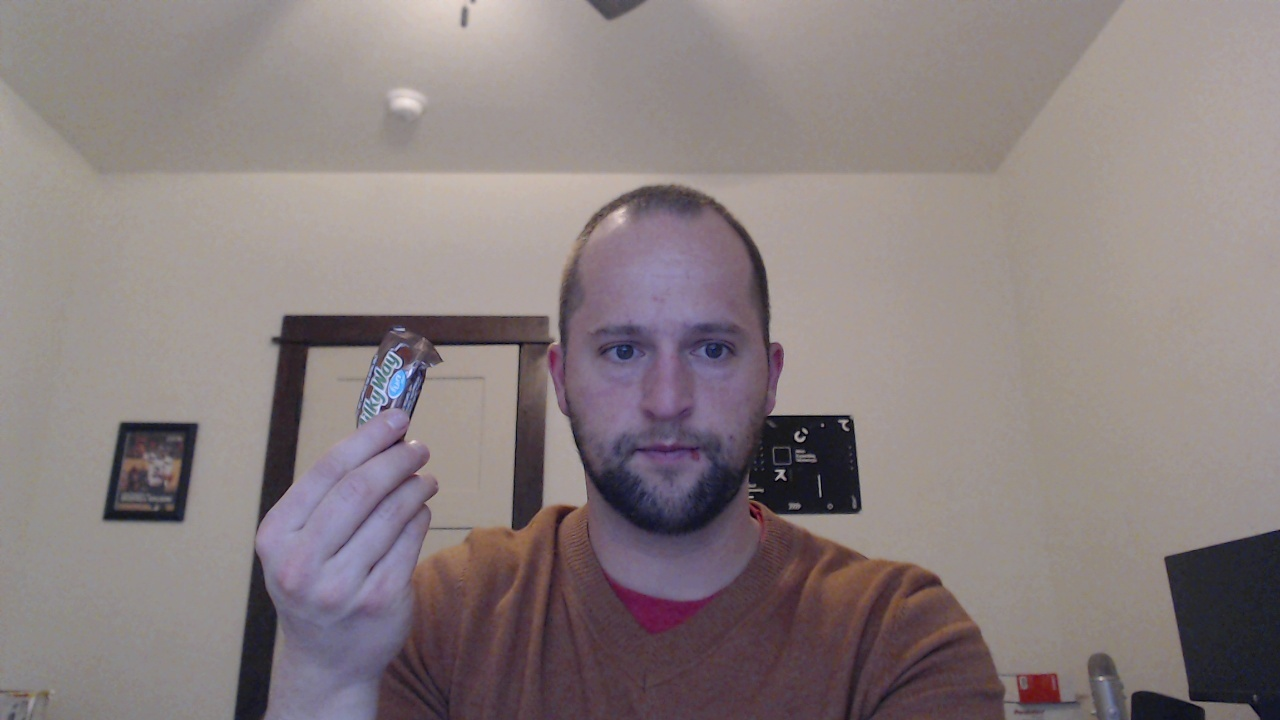

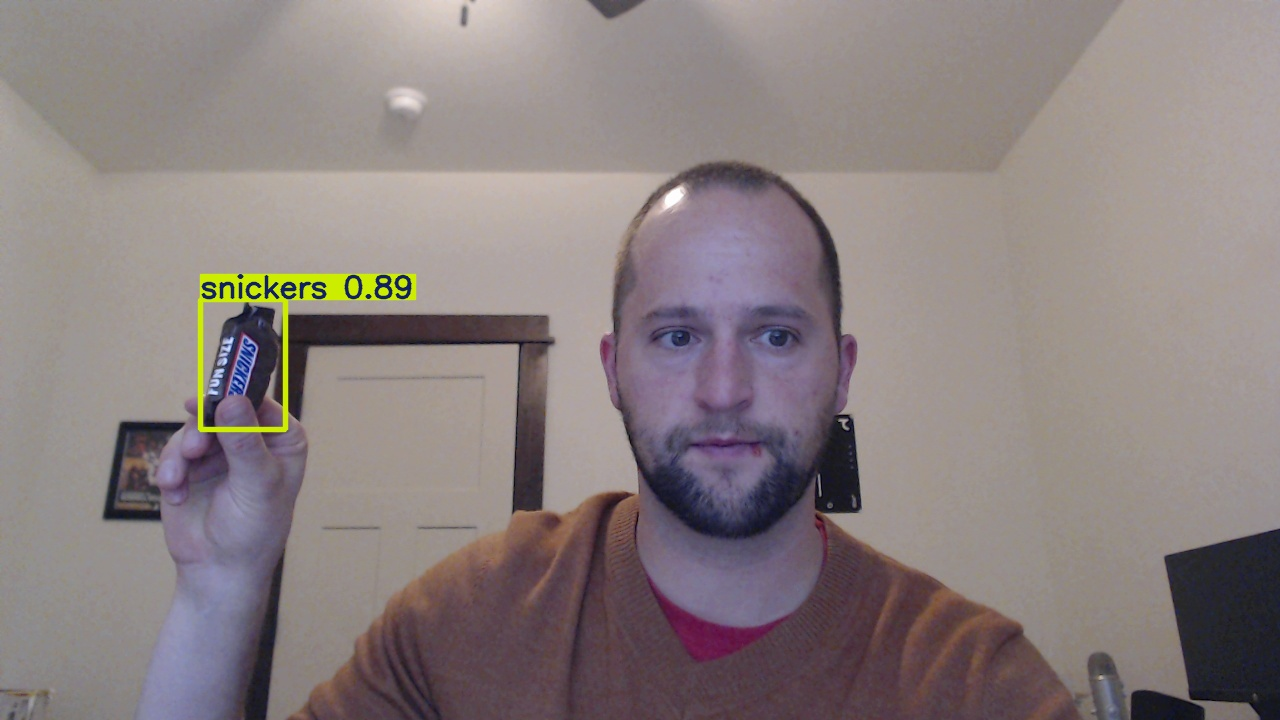

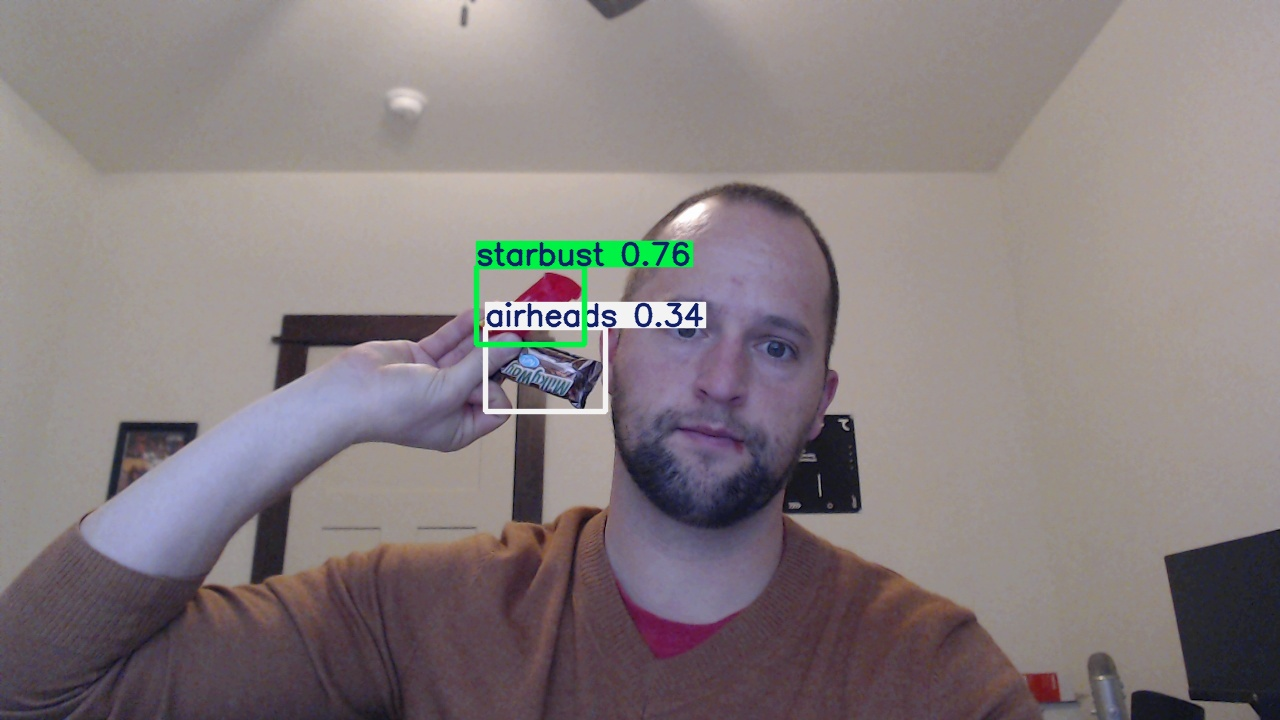

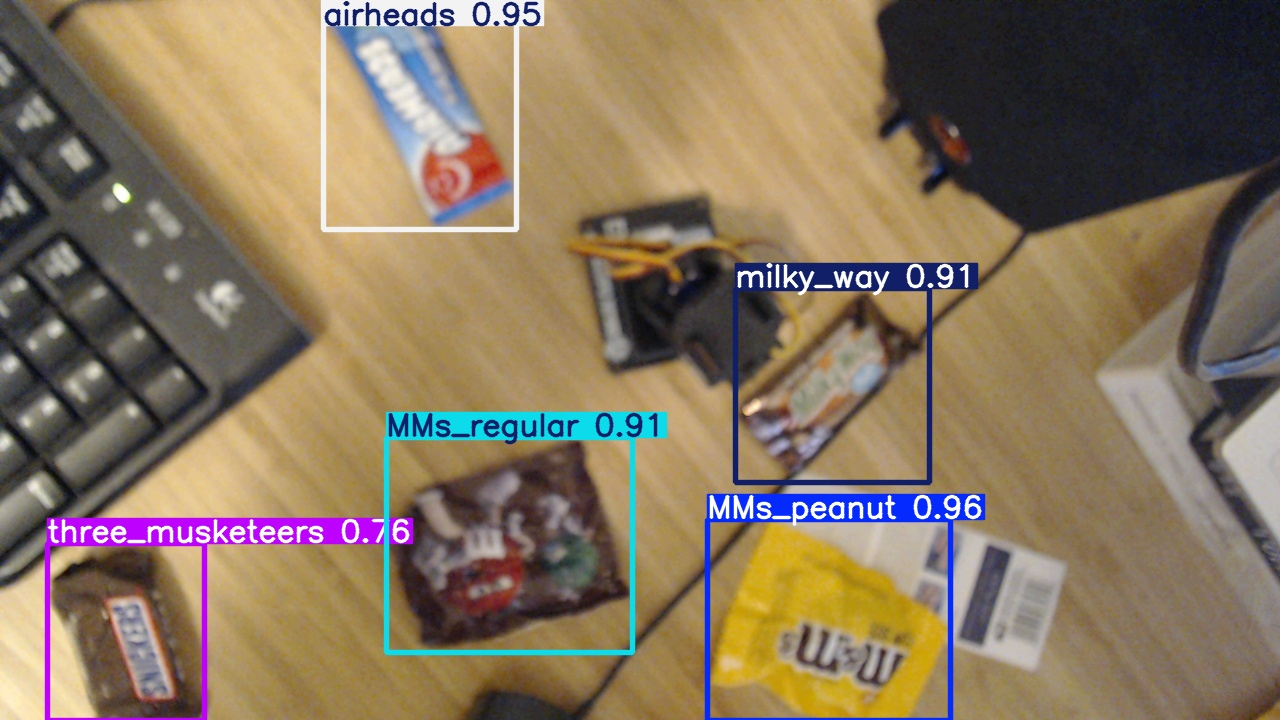

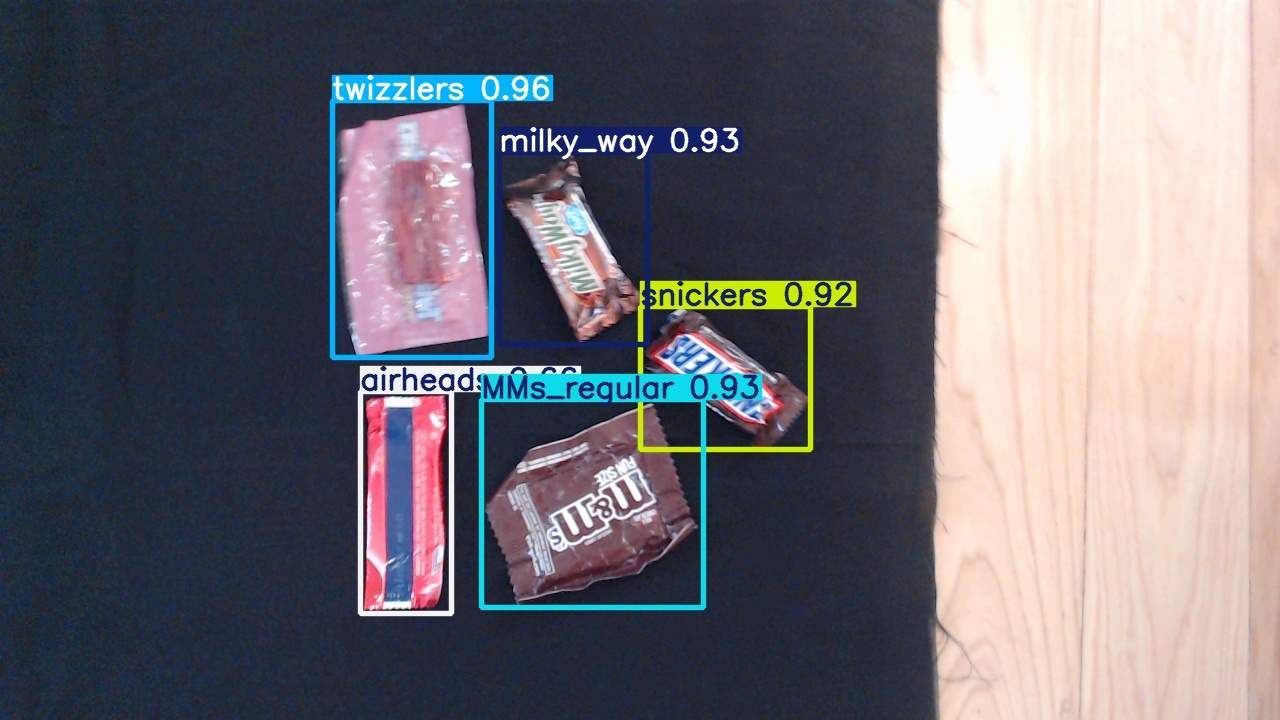

In [ ]:
import glob
from IPython.display import Image, display
for image_path in glob.glob(f'/content/runs/detect/predict/*.jpg')[:10]:
  display(Image(filename=image_path, height=400))
  print('\n')

The model should draw a box around each object of interest in each image. If it isn't doing a good job of detecting objects, here are a few tips:

1. Double-check your dataset to make sure there are no labeling errors or conflicting examples.
2. Increase the number of epochs used for training.
3. Use a larger model size (e.g. `yolo11l.pt`).
4. Add more images to the training dataset. See my [dataset video](https://www.youtube.com/watch?v=v0ssiOY6cfg) for tips on how to capture good training images and improve accuracy.

You can also run the model on video files or other images images by uploading them to this notebook and using the above `!yolo detect predict` command, where `source` points to the location of the video file, image, or folder of images. The results will be saved in `runs/detect/predict`.

Drawing boxes on images is great, but it isn't very useful in itself. It's also not very helpful to just run this models inside a Colab notebook: it's easier if we can just run it on a local computer. Continue to the next section to see how to download your newly trained model and run it on a local device.

#7.&nbsp;Deploy Model

Now that your custom model has been trained, it's ready to be downloaded and deployed in an application! YOLO models can run on a wide variety of hardware, including PCs, embedded systems, and phones. Ultralytics makes it easy to convert the YOLO models to various formats (`tflite`, `onnx`, etc.) and deploy them in a variety of environments.

This section shows how to download the model and provides links to instructions for deploying it on your PC and edge devices like the Raspberry Pi.

## 7.1 Download YOLO Model

First, zip and download the trained model by running the code blocks below.

The code creates a folder named `my_model`, moves the model weights into it, and renames them from `best.pt` to `my_model.pt`. It also adds the training results in case you want to reference them later. It then zips the folder as `my_model.zip`.

In [ ]:
# Create "my_model" folder to store model weights and train results
!mkdir /content/my_model
!cp /content/runs/detect/train/weights/best.pt /content/my_model/my_model.pt
!cp -r /content/runs/detect/train /content/my_model

# Zip into "my_model.zip"
%cd my_model
!zip /content/my_model.zip my_model.pt
!zip -r /content/my_model.zip train
%cd /content

/content/my_model
  adding: my_model.pt (deflated 8%)
  adding: train/ (stored 0%)
  adding: train/BoxR_curve.png (deflated 10%)
  adding: train/BoxF1_curve.png (deflated 7%)
  adding: train/train_batch502.jpg (deflated 12%)
  adding: train/train_batch501.jpg (deflated 15%)
  adding: train/weights/ (stored 0%)
  adding: train/weights/last.pt (deflated 8%)
  adding: train/weights/best.pt (deflated 8%)
  adding: train/train_batch2.jpg (deflated 5%)
  adding: train/train_batch1.jpg (deflated 4%)
  adding: train/BoxP_curve.png (deflated 9%)
  adding: train/results.png (deflated 7%)
  adding: train/val_batch0_pred.jpg (deflated 9%)
  adding: train/args.yaml (deflated 53%)
  adding: train/confusion_matrix_normalized.png (deflated 18%)
  adding: train/val_batch0_labels.jpg (deflated 9%)
  adding: train/BoxPR_curve.png (deflated 15%)
  adding: train/train_batch500.jpg (deflated 9%)
  adding: train/confusion_matrix.png (deflated 22%)
  adding: train/labels.jpg (deflated 29%)
  adding: train/res

In [ ]:
# This takes forever for some reason, you can also just download the model from the sidebar
from google.colab import files

files.download('/content/my_model.zip')

## 7.2 Deploy YOLO Model on Local Devices

Next, we'll take our downloaded model and run it on a local device. This section provides instructions showing how to deploy YOLO models on various devices.

I wrote a basic Python script, `yolo_detect.py`, that shows how to load a model, run inference on an image source, parse the inference results, and display boxes around each detected class in the image. The [script](https://github.com/EdjeElectronics/Train-and-Deploy-YOLO-Models/blob/main/yolo_detect.py) gives an example of how to work with Ultralytics YOLO models in Python, and it can be used as a starting point for more advanced applications.

### 7.2.1 Deploy on PC (Windows, Linux, or macOS)

The easiest way to run Ultralytics models on a PC is using Anaconda. Anaconda sets up a virtual Python environment and allows you to easily install Ultralytics and PyTorch. It automatically installs CUDA and cuDNN, which allows you to speed up model inference with your NVIDIA GPU.

> **NOTE:** My YouTube video (link to be added) shows how to deploy your model on a PC. It walks through the following steps, so watch the video if you prefer having visual instructions.

**1. Download and Install Anaconda**

Go to the Anaconda download page at https://anaconda.com/download, click the “skip registration” button, and then download the package for your OS. When it's finished downloading, run the installer and click through the installation steps. You can use the default options for installation.

**2. Set up virtual environment**

Once it's installed, run Anaconda Prompt from the Start Bar. (If you're on macOS or Linux, just open a command terminal).

Issue the following commands to create a new Python environment and activate it:

```
conda create --name yolo-env1 python=3.12 -y
conda activate yolo-env1
```

Install Ultralytics (which also installs import libraries like OpenCV-Python, Numpy, and PyTorch) by issuing the following command:

```
pip install ultralytics
```

If you have an NVIDIA GPU, you can install the GPU-enabled version of PyTorch by issuing the following command:

```
pip install --upgrade torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124
```

**3. Extract downloaded model**
Take the `my_model.zip` file you downloaded in Step 7.1 and unzip it to a folder on your PC. In the Anaconda Prompt terminal, move into the unzipped folder using:

```
cd path/to/folder
```

**4. Download and run yolo_detect.py**

Download the `yolo_detect.py` script into the `my_model` folder using:

```
curl -o yolo_detect.py https://raw.githubusercontent.com/EdjeElectronics/Train-and-Deploy-YOLO-Models/refs/heads/main/yolo_detect.py
```

Alright! We're ready to run the script. To run inference with a yolov8s model on a USB camera at 1280x720 resolution, issue:

```
python yolo_detect.py --model my_model.pt --source usb0 --resolution 1280x720
```

A window will appear showing a live feed from your webcam with boxes drawn around detected objects in each frame.

You can also run the model on an video file, image, or folder of images. To see a full list of arguments for `yolo_detect.py`, issue `python yolo_detect.py --help` or see the [README file](https://github.com/EdjeElectronics/Train-and-Deploy-YOLO-Models/blob/main/README.md).




### 7.2.2 Deploy on Raspberry Pi

Keep an eye out for an article showing how to convert YOLO models to NCNN format and run them on the Raspberry Pi!

# 8.&nbsp;Conclusion

Congratulations! You've successfully trained and deployed a YOLO object detection model. 😀

Next, you can extend your application beyond just drawing boxes and counting objects. Add functionality like logging the number of objects detected over time or taking a picture when certain objects are detected. Check out some example applications at our GitHub repository: https://github.com/EdjeElectronics/Train-and-Deploy-YOLO-Models

Thanks for working through this notebook, and good luck with your projects!

# Appendix: Common Errors

If you run into any errors working through this notebook, please do the following:


- Double-check that the dataset files are set up in the correct folder structure
- Make sure there are no typos or errors in your labelmap file
- Google search the error to look for solutions

If none of those help, please submit an [Issue](https://github.com/EdjeElectronics/Train-and-Deploy-YOLO-Models/issues) on the GitHub page. In this section, I will add resolutions to common errors as they come up.